# 01.01 - PROYECTO KAGGLE

In [ ]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources


## download data directly from Kaggle

- create a file `kaggle.json` with your authentication token (in kaggle $\to$ click user icon on top-right $\to$ settings $\to$ API create new token)
- upload it to this notebook workspace
- run the following cell

In [2]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download -c udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 1.37GB/s]


## unzip and inspect data

In [3]:
!unzip udea*.zip > /dev/null

In [ ]:
!wc *.csv

   296787    296787   4716673 submission_example.csv
   296787   4565553  50135751 test.csv
   692501  10666231 118025055 train.csv
  1286075  15528571 172877479 total


## load `train.csv` data with pandas



In [6]:
import pandas as pd
import numpy as np

z = pd.read_csv("train.csv")
print ("shape of loaded dataframe", z.shape)


shape of loaded dataframe (692500, 21)


In [5]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,...,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,...,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,...,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,...,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,...,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


In [19]:
import matplotlib.pyplot as plt
# Analisis exploratorio
print("Dimensiones del dataset:", z.shape)
print("\nTipos de datos:\n", z.dtypes)
# Primeras filas
print("\nPrimeras filas:\n", z.head())

Dimensiones del dataset: (692500, 21)

Tipos de datos:
 ID                               int64
PERIODO_ACADEMICO                int64
E_PRGM_ACADEMICO                object
E_PRGM_DEPARTAMENTO             object
E_VALORMATRICULAUNIVERSIDAD     object
E_HORASSEMANATRABAJA            object
F_ESTRATOVIVIENDA               object
F_TIENEINTERNET                 object
F_EDUCACIONPADRE                object
F_TIENELAVADORA                 object
F_TIENEAUTOMOVIL                object
E_PRIVADO_LIBERTAD              object
E_PAGOMATRICULAPROPIO           object
F_TIENECOMPUTADOR               object
F_TIENEINTERNET.1               object
F_EDUCACIONMADRE                object
RENDIMIENTO_GLOBAL              object
INDICADOR_1                    float64
INDICADOR_2                    float64
INDICADOR_3                    float64
INDICADOR_4                    float64
dtype: object

Primeras filas:
        ID  PERIODO_ACADEMICO            E_PRGM_ACADEMICO E_PRGM_DEPARTAMENTO  \
0  904256    

In [20]:
# ==============================
# Análisis de la variable objetivo
# ==============================
rendimiento_counts = z["RENDIMIENTO_GLOBAL"].value_counts()
print("\nDistribución de RENDIMIENTO_GLOBAL:\n", rendimiento_counts)


Distribución de RENDIMIENTO_GLOBAL:
 RENDIMIENTO_GLOBAL
alto          175619
bajo          172987
medio-bajo    172275
medio-alto    171619
Name: count, dtype: int64


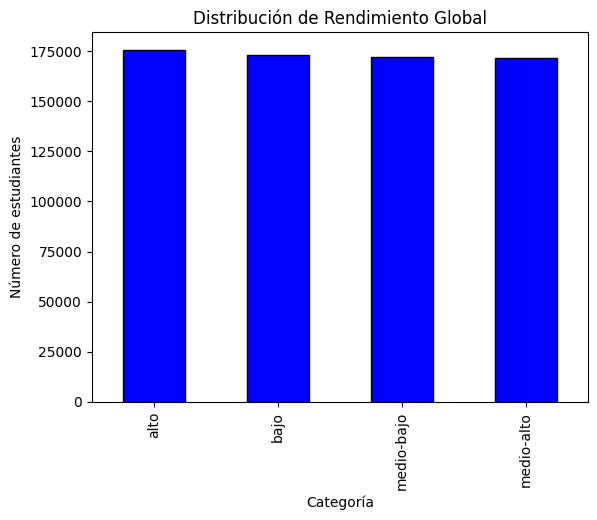

In [22]:
# =================
# Gráfico de barras
# =================
rendimiento_counts.plot(kind="bar", color="blue", edgecolor="black")
plt.title("Distribución de Rendimiento Global")
plt.xlabel("Categoría")
plt.ylabel("Número de estudiantes")
plt.show()


Top 10 Programas Académicos:
 E_PRGM_ACADEMICO
DERECHO                       53244
ADMINISTRACION DE EMPRESAS    51902
CONTADURIA PUBLICA            39664
PSICOLOGIA                    31932
INGENIERIA INDUSTRIAL         28481
ADMINISTRACIÓN DE EMPRESAS    24777
INGENIERIA CIVIL              19487
MEDICINA                      18099
PSICOLOGÍA                    17377
INGENIERIA DE SISTEMAS        17150
Name: count, dtype: int64


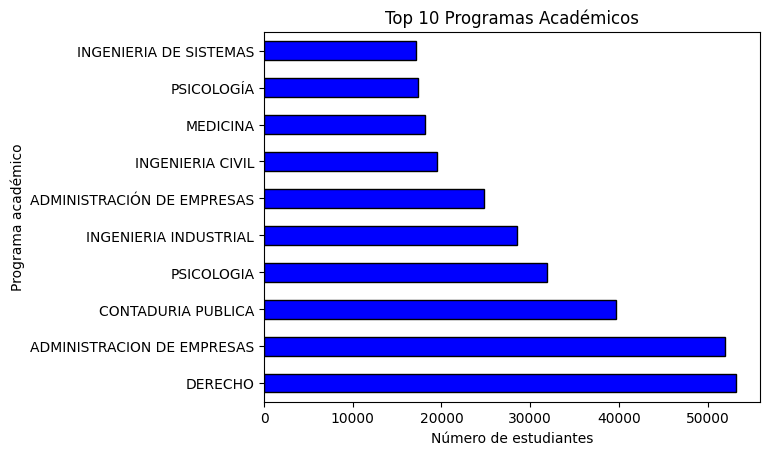

In [24]:
# ==============================
# Programas académicos más comunes
# ==============================
program_counts = z["E_PRGM_ACADEMICO"].value_counts().head(10)
print("\nTop 10 Programas Académicos:\n", program_counts)

program_counts.plot(kind="barh", color="blue", edgecolor="black")
plt.title("Top 10 Programas Académicos")
plt.xlabel("Número de estudiantes")
plt.ylabel("Programa académico")
plt.show()


Top 10 Departamentos:
 E_PRGM_DEPARTAMENTO
BOGOTÁ             282159
ANTIOQUIA           83607
VALLE               44588
ATLANTICO           41020
SANTANDER           28828
NORTE SANTANDER     22588
BOLIVAR             20629
BOYACA              14048
CUNDINAMARCA        14018
NARIÑO              13454
Name: count, dtype: int64


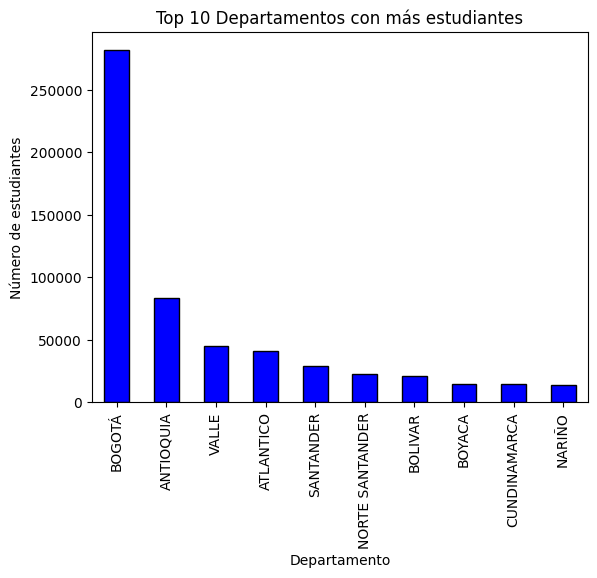

In [25]:
# ==============================
# Departamentos con más estudiantes
# ==============================
dept_counts = z["E_PRGM_DEPARTAMENTO"].value_counts().head(10)
print("\nTop 10 Departamentos:\n", dept_counts)

dept_counts.plot(kind="bar", color="blue", edgecolor="black")
plt.title("Top 10 Departamentos con más estudiantes")
plt.xlabel("Departamento")
plt.ylabel("Número de estudiantes")
plt.show()


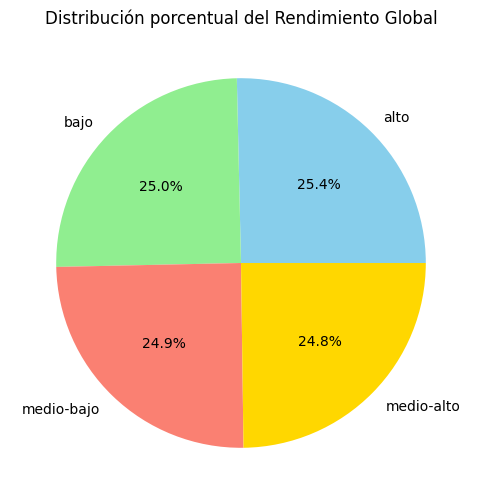

In [26]:
# =================
# Gráfico de pastel
# =================
rendimiento_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6), colors=["skyblue","lightgreen","salmon","gold"])

plt.title("Distribución porcentual del Rendimiento Global")
plt.ylabel("")  # Quita la etiqueta del eje Y
plt.show()


## Send your submission to Kaggle

You must **join the competition** first

In [ ]:
!kaggle competitions submit -c udea-ai4eng-20242 -f my_submission.csv -m "raul ramos submission with linear model"

100% 3.88M/3.88M [00:00<00:00, 5.57MB/s]
Successfully submitted to UDEA/ai4eng 20242 - Pruebas Saber Pro Colombia